# Bioreactor — mathematical model

**Algae growth · mussel clearance · feeding control**

Our reactor couples two living processes:

1. **Algae grow** in the algae tank (a food source).
2. **Mussels eat algae** in the mussel tank by filtering the water ("clearance").

The model answers three questions the project actually needs:

* How fast do the mussels eat? → the **clearance rate** sets everything.
* How much / how often must we **feed** to hold the food at the right level?
* Can the algae tank **supply** that much food (sustainability)?

Everything below is written so each function maps to one physical idea, with the
lab-measured inputs flagged `>>> LAB`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Algae growth model

Algae multiply. Early on the growth is **exponential**:

$$N(t) = N_0\,e^{\mu t}$$

where $\mu$ is the **specific growth rate** (per day). Measuring the density at two
times gives $\mu$ directly:

$$\mu = \frac{\ln(N_t/N_0)}{t}$$

Real cultures can't grow forever — nutrients and light run out — so the honest model
is **logistic**, which levels off at a carrying capacity $K$:

$$\frac{dN}{dt} = \mu N\left(1 - \frac{N}{K}\right)$$

## 2. Mussel clearance rate — and yes, we need it

**Do we need the clearance rate? Yes — it is the central parameter of the whole model.**
It tells us how fast the mussels remove algae, which sets the feed rate, the algae
demand and even the OD signal we expect to see.

**Clearance rate (CR)** = the volume of water a mussel completely strips of particles
per hour, in **L/ind/h**.

In a closed, well-mixed tank with no feeding, $N$ mussels make the algae concentration
fall **exponentially**:

$$C(t) = C_0\,e^{-g t}, \qquad g = \frac{N\,CR}{V}$$

$g$ is the **grazing coefficient** (per hour). Rearranging gives the **indirect method**
to *measure* clearance from two concentration readings — exactly what our OD sensor
provides between feeds:

$$CR = \frac{V\,g}{N}, \qquad g = \frac{\ln(C_1/C_2)}{t_2-t_1}$$

So we can get CR two ways: (a) a one-off **lab decline experiment**, or (b) **live**,
from the OD drop between feeds. (This also fixes the old `filtration_rate`, which
referenced the function name instead of the value `g`.)

## 3. Feeding model

We keep the food in a **band**: top it up to `C_target` and let the mussels graze it
down to `band_low * C_target`, then feed again.

**How much to dose.** To raise the tank from $C_{cur}$ to $C_{tar}$ by adding a volume
$v$ (mL) of stock at density $A$ into tank volume $V$ (converted to mL):

$$v = \frac{V\,(C_{tar}-C_{cur})}{A - C_{tar}}$$

**How long to run the pump:** $t_{pump} = v / \text{pump flow}$.

**How often to feed.** Between feeds the concentration decays at rate $g$, so the time
to fall from $C_{tar}$ to $C_{low}$ is:

$$\Delta t = \frac{\ln(C_{tar}/C_{low})}{g}$$

**How much food the mussels eat** (the demand we must supply): at concentration $C$,
$$\text{consumption} = N\,CR\,C \;\;[\text{cells/h}]\;(\times 1000\,\text{mL/L}).$$

## 4. Simulation — feeding control over time

This is the model running as the controller will: each step the mussels clear algae;
when the concentration hits the lower band we dose back to target. The result is the
familiar **sawtooth** — and it's exactly the feeding loop in our control-code diagram.
This is the plot to bring to the review (add your measured points + error bars on top).

## 5. Sustainability — can the algae tank keep up?

A mass balance: the algae tank **produces** cells by growth; the mussels **consume**
them. For the system to run without buying algae, production must exceed consumption.

Production in the exponential phase ≈ $\mu \times (\text{cells in the algae tank})$.
If the ratio below is **< 1**, the algae can't keep up and you must grow more (bigger
or denser algae tank), feed fewer mussels, or accept periodic restocking.

## Do we need the clearance rate? (short answer)

**Yes — it is the keystone.** Clearance rate (CR) drives:

* the grazing coefficient $g = N\,CR/V$ → how fast food disappears,
* the **feed interval** and **dose** (Section 3),
* the **algae demand** and therefore the sustainability check (Section 5),
* the **expected OD decline** between feeds, which the controller uses live.

Get it once from a lab decline experiment, then keep re-estimating it live from the OD
drop between feeds with `grazing_coefficient` + `clearance_rate_from_decline`.


## What data we need from the lab

| # | Quantity | Symbol / var | How to measure it |
|---|----------|--------------|-------------------|
| 1 | **Clearance rate** | `CR` [L/ind/h] | Closed-beaker decline: N mussels in known volume V, sample algae conc at t1,t2 → `grazing_coefficient` → `clearance_rate_from_decline`. Record **temperature** and **mussel size**. |
| 2 | **Algae growth rate** | `mu` [1/day] (and `K`) | Track algae density over several days; fit `specific_growth_rate` / logistic. |
| 3 | **OD ↔ cells calibration** | — | Dilution series of known cell counts vs OD sensor reading (and vs haemocytometer counts). Turns sensor output into cells/mL. |
| 4 | **Target food concentration** | `C_target` [cells/mL] | From literature/experiment for your species; **confirm the units of 1.338**. Also the lower band. |
| 5 | **Mussel size / dry weight** | — | Clearance scales with body mass; record mean size and N (allometry). |
| 6 | **Algae stock density** | `A` [cells/mL] | Count the feed-tank density before feeding. |
| 7 | **Pump calibration** | `pump_flow` [mL/min] | Gravimetric: weigh water pumped in a fixed time at your PWM setting. |
| 8 | **Temperature** | T [°C] | Both CR and mu depend on T; log/control at your 17-18 °C. |
| 9 | **Tank volumes** | `V_m`, `V_a` [L] | Measure actual water volumes. |
| 10 | **(optional) O₂ + ammonia** | — | Dissolved O₂ (for the air-pump decision) and ammonia (water quality / 'are mussels happy'). |

With items 1-4 you can already run and validate the whole model; the rest tighten the
numbers and feed the other RM3 slides.

In [10]:
import math

def calculate_concentration_after_time(C0, F, N, V, time_hours):
    """
    Calculates the concentration in the mussel tank after a specific amount 
    of time using the model: C_t = C_0 * exp(-g * t)
    
    Parameters:
    C0 (float): Initial concentration in the tank (cells/mL)
    F (float): Clearance rate of the mussel (Liters/hour)
    N (int): Number of mussels
    V (float): Total volume of the mussel tank (Liters)
    time_hours (float): Time elapsed (t) in hours
    
    Returns:
    tuple: (Final concentration C_t, Calculated grazing coefficient g)
    """
    
    # Calculate the grazing coefficient (g)
    # g = (Clearance Rate * Number of Mussels) / Tank Volume
    g = (F * N) / V
    
    # Calculate the new concentration after time t
    # Using the exact exponential decay formula requested
    C_t = C0 * math.exp(-g * time_hours)
    
    return C_t, g

# --- Main Execution ---
if __name__ == "__main__":
    # Define the starting variables based on your established optimal state
    initial_concentration = 1338.0  # C_0 (cells/mL)
    clearance_rate = 2.5           # F (Liters/hour)
    number_of_mussels = 1           # N 
    tank_volume = 4.0               # V (Liters)
    
    # Set the time interval (t) you want to test (e.g., 0.5 for 30 minutes)
    time_t = 0.5 

    print("--- Step 1: Concentration Decay Simulation ---")
    print(f"Starting Concentration (C_0): {initial_concentration} cells/mL")
    print(f"Time Elapsed (t): {time_t} hours\n")
    
    # Run the calculation
    C_t, calculated_g = calculate_concentration_after_time(
        initial_concentration, 
        clearance_rate, 
        number_of_mussels, 
        tank_volume, 
        time_t
    )
    
    print(f"Calculated Grazing Coefficient (g): {calculated_g:.4f} hr^-1")
    print(f"Final Concentration (C_t): {C_t:.2f} cells/mL")
    print(f"Total drop in concentration: {(initial_concentration - C_t):.2f} cells/mL")

--- Step 1: Concentration Decay Simulation ---
Starting Concentration (C_0): 1338.0 cells/mL
Time Elapsed (t): 0.5 hours

Calculated Grazing Coefficient (g): 0.6250 hr^-1
Final Concentration (C_t): 978.90 cells/mL
Total drop in concentration: 359.10 cells/mL


In [11]:
def calculate_new_concentration(C_tank, V_tank, C_pumped, V_pumped):
    C_new = (C_tank*V_tank)+(C_pumped*V_pumped)/(V_tank + V_pumped)
    return C_new

if __name__ == "__main__":
    # Define the starting variables based on your established optimal state
    initial_concentration = 1338.0  # C_0 (cells/mL)
    clearance_rate = 3.46           # F (Liters/hour)
    number_of_mussels = 1           # N 
    tank_volume = 4.0               # V (Liters)
    
    # Set the time interval (t) you want to test (e.g., 0.5 for 30 minutes)
    time_t = 0.5 

    print("--- Step 1: Concentration Decay Simulation ---")
    print(f"Starting Concentration (C_0): {initial_concentration} cells/mL")
    print(f"Time Elapsed (t): {time_t} hours\n")
    
    # Run the calculation for Step 1
    C_t, calculated_g = calculate_concentration_after_time(
        initial_concentration, 
        clearance_rate, 
        number_of_mussels, 
        tank_volume, 
        time_t
    )
    
    print(f"Calculated Grazing Coefficient (g): {calculated_g:.4f} hr^-1")
    print(f"Final Concentration (C_t): {C_t:.2f} cells/mL")
    print(f"Total drop in concentration: {(initial_concentration - C_t):.2f} cells/mL\n")

    print("--- Step 2: Dosing / Concentration Adjustment ---")
    # Define the variables for the algae reservoir and the dosing pump
    # Note: V_pumped is converted to Liters so it matches the V_tank unit!
    reservoir_concentration = 250000.0  # C_pumped (cells/mL)
    volume_to_pump_liters = 0.015       # V_pumped (15 mL = 0.015 L)

    print(f"Reservoir Concentration (C_pumped): {reservoir_concentration} cells/mL")
    print(f"Volume Pumped (V_pumped): {volume_to_pump_liters * 1000} mL")
    
    # Run the calculation for Step 2
    C_new = calculate_new_concentration(
        C_tank=C_t, 
        V_tank=tank_volume, 
        C_pumped=reservoir_concentration, 
        V_pumped=volume_to_pump_liters
    )
    
    print(f"Adjusted Concentration (C_new): {C_new:.2f} cells/mL")
    

--- Step 1: Concentration Decay Simulation ---
Starting Concentration (C_0): 1338.0 cells/mL
Time Elapsed (t): 0.5 hours

Calculated Grazing Coefficient (g): 0.8650 hr^-1
Final Concentration (C_t): 868.21 cells/mL
Total drop in concentration: 469.79 cells/mL

--- Step 2: Dosing / Concentration Adjustment ---
Reservoir Concentration (C_pumped): 250000.0 cells/mL
Volume Pumped (V_pumped): 15.0 mL
Adjusted Concentration (C_new): 4406.83 cells/mL


In [12]:
import math

def calculate_concentration_after_time(C0, F, N, V, time_hours):
    """
    Calculates the concentration in the mussel tank after a specific amount 
    of time using the model: C_t = C_0 * exp(-g * t)
    
    Parameters:
    C0 (float): Initial concentration in the tank (cells/mL)
    F (float): Clearance rate of the mussel (Liters/hour)
    N (int): Number of mussels
    V (float): Total volume of the mussel tank (Liters)
    time_hours (float): Time elapsed (t) in hours
    
    Returns:
    tuple: (Final concentration C_t, Calculated grazing coefficient g)
    """
    
    # Calculate the grazing coefficient (g)
    # g = (Clearance Rate * Number of Mussels) / Tank Volume
    g = (F * N) / V
    
    # Calculate the new concentration after time t
    # Using the exact exponential decay formula requested
    C_t = C0 * math.exp(-g * time_hours)
    
    return C_t, g

def calculate_new_concentration(C_tank, V_tank, C_pumped, V_pumped):
    """
    Calculates the new concentration after injecting algae water into the tank.
    Using the mass balance formula: 
    C_new = ((C_tank * V_tank) + (C_pumped * V_pumped)) / (V_tank + V_pumped)
    
    Parameters:
    C_tank (float): Current concentration in the main tank (cells/mL)
    V_tank (float): Volume of the main tank (Liters)
    C_pumped (float): Concentration of the algae reservoir (cells/mL)
    V_pumped (float): Volume of algae water pumped into the tank (Liters)
    
    Returns:
    float: The adjusted concentration (C_new) in cells/mL
    """
    
    # Calculate the new adjusted concentration
    C_new = ((C_tank * V_tank) + (C_pumped * V_pumped)) / (V_tank + V_pumped)
    
    return C_new

def calculate_required_volume(C_target, C_tank, V_tank, C_pumped):
    """
    Rearranges the mass balance formula to calculate the exact volume of 
    algae water (V_pumped) needed to reach the target concentration.
    
    Parameters:
    C_target (float): The optimal concentration we want to reach (cells/mL)
    C_tank (float): Current dropped concentration in the main tank (cells/mL)
    V_tank (float): Volume of the main tank (Liters)
    C_pumped (float): Concentration of the algae reservoir (cells/mL)
    
    Returns:
    float: Volume of algae water to pump (Liters)
    """
    if C_pumped <= C_target:
        return 0.0 # Safety check to prevent negative volume
        
    # Rearranged formula: V_pumped = (V_tank * (C_target - C_tank)) / (C_pumped - C_target)
    V_pumped = (V_tank * (C_target - C_tank)) / (C_pumped - C_target)
    
    return V_pumped

# --- Main Execution ---
if __name__ == "__main__":
    # Define the starting variables based on your established optimal state
    optimal_concentration = 1338.0  # C_0 / C_target (cells/mL)
    clearance_rate = 3.46           # F (Liters/hour)
    number_of_mussels = 1           # N 
    tank_volume = 4.0               # V (Liters)
    reservoir_concentration = 250000.0  # C_pumped (cells/mL)
    
    # Set the time interval (t) between checks
    time_t = 0.1 # 30 minutes
    
    # Start the system at the optimal concentration
    current_concentration = optimal_concentration

    print("--- Starting Autonomous Closed-Loop Feeding Simulation ---\n")
    
    # Simulate 3 continuous feeding cycles
    cycles_to_simulate = 3
    
    for cycle in range(1, cycles_to_simulate + 1):
        print(f"=== CYCLE {cycle} ===")
        print(f"Initial State: {current_concentration:.2f} cells/mL")
        
        # --- Step 1: Concentration Decay ---
        C_t, calculated_g = calculate_concentration_after_time(
            C0=current_concentration, 
            F=clearance_rate, 
            N=number_of_mussels, 
            V=tank_volume, 
            time_hours=time_t
        )
        print(f"  -> After {time_t} hours of grazing: Dropped to {C_t:.2f} cells/mL")
        
        # --- Step 2: Calculate Required Volume ---
        volume_to_pump_liters = calculate_required_volume(
            C_target=optimal_concentration,
            C_tank=C_t,
            V_tank=tank_volume,
            C_pumped=reservoir_concentration
        )
        print(f"  -> Pumping {volume_to_pump_liters * 1000:.2f} mL of dense algae water...")
        
        # --- Step 3: Dosing & Verification ---
        C_new = calculate_new_concentration(
            C_tank=C_t, 
            V_tank=tank_volume, 
            C_pumped=reservoir_concentration, 
            V_pumped=volume_to_pump_liters
        )
        print(f"  -> Final Adjusted Concentration: {C_new:.2f} cells/mL\n")
        
        # Set the current concentration to the newly adjusted state for the next loop
        current_concentration = C_new

--- Starting Autonomous Closed-Loop Feeding Simulation ---

=== CYCLE 1 ===
Initial State: 1338.00 cells/mL
  -> After 0.1 hours of grazing: Dropped to 1227.13 cells/mL
  -> Pumping 1.78 mL of dense algae water...
  -> Final Adjusted Concentration: 1338.00 cells/mL

=== CYCLE 2 ===
Initial State: 1338.00 cells/mL
  -> After 0.1 hours of grazing: Dropped to 1227.13 cells/mL
  -> Pumping 1.78 mL of dense algae water...
  -> Final Adjusted Concentration: 1338.00 cells/mL

=== CYCLE 3 ===
Initial State: 1338.00 cells/mL
  -> After 0.1 hours of grazing: Dropped to 1227.13 cells/mL
  -> Pumping 1.78 mL of dense algae water...
  -> Final Adjusted Concentration: 1338.00 cells/mL



Plot saved as 'mussel_feeding_simulation_dynamic.png'


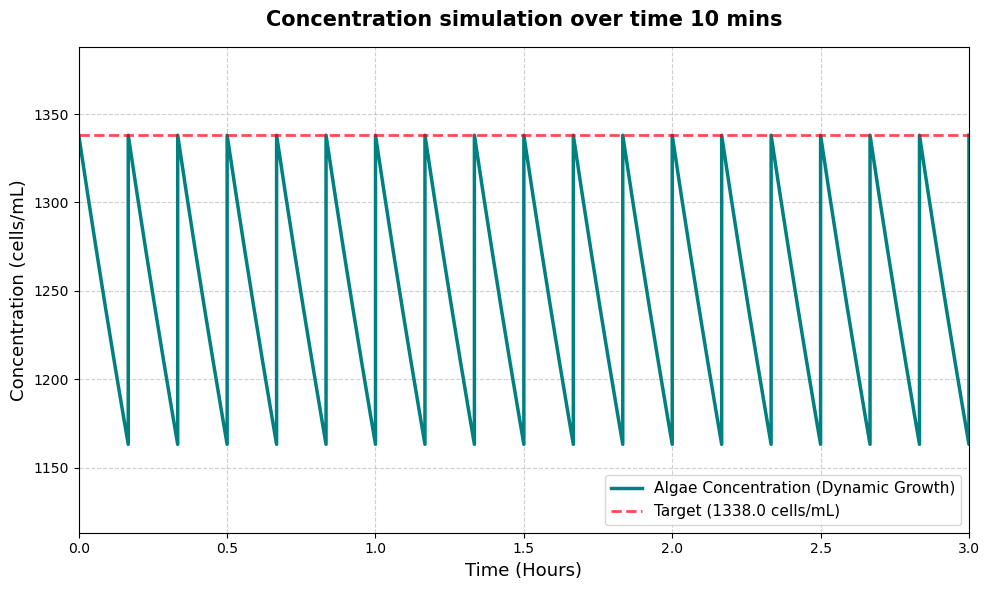

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
C_TARGET = 1338.0      # Target concentration (cells/mL)
F_RATE = 3.46          # Clearance rate (Liters/hour)
N_MUSSELS = 1          # Number of mussels
V_TANK = 4.0           # Tank volume (Liters)
C_PUMPED = 250000.0    # Algae reservoir concentration (cells/mL)
TIME_T = 10 / 60.0     # Sampling interval (10 minutes in hours)
CYCLES = 18            # Number of feeding cycles to simulate (18 cycles * 10 mins = 3 hours)

# --- New Algae Growth Parameters ---
MU_MAX = 0.035         # Maximum specific growth rate (hr^-1)
K_CAPACITY = 5000.0    # Carrying capacity of the tank (cells/mL)

def simulate_feeding_loop():
    """Simulates the discrete time feeding loop with dynamic algae growth."""
    time_points = []
    conc_points = []
    
    current_time = 0.0
    current_c = C_TARGET
    
    for _ in range(CYCLES):
        # Step 1: Dynamic Decay & Growth (Euler Method)
        # We use numerical integration to handle the non-constant growth rate
        t_steps = 50
        dt = TIME_T / t_steps
        
        t_interval = []
        c_interval = []
        
        c_sim = current_c
        
        for step in range(t_steps):
            # Calculate dynamic growth rate (Logistic Growth)
            # As concentration gets closer to carrying capacity, growth slows down
            k_dynamic = MU_MAX * (1 - (c_sim / K_CAPACITY))
            
            # Constant grazing coefficient
            g = (F_RATE * N_MUSSELS) / V_TANK
            
            # Net change: Growth - Grazing
            dC_dt = (k_dynamic * c_sim) - (g * c_sim)
            
            c_sim += dC_dt * dt
            
            t_interval.append(current_time + (step + 1) * dt)
            c_interval.append(c_sim)
            
        # Add these points to our plotting lists
        time_points.extend(t_interval)
        conc_points.extend(c_interval)
        
        # Move the clock forward by TIME_T
        current_time += TIME_T
        
        # The concentration right before dosing is the last point in our interval
        C_t = c_interval[-1]
        
        # Step 2: Dosing Calculation
        v_pumped = 0.0
        if C_PUMPED > C_TARGET:
            # Volume to pump = (V_tank * Deficit) / (Pump_Concentration - Target)
            v_pumped = (V_TANK * (C_TARGET - C_t)) / (C_PUMPED - C_TARGET)
            
        # Step 3: Adjustment Calculation (Mass Balance)
        C_new = ((C_t * V_TANK) + (C_PUMPED * v_pumped)) / (V_TANK + v_pumped)
        
        # Record the vertical spike from immediate dosing
        time_points.append(current_time)
        conc_points.append(C_new)
        
        # Reset current concentration for the next cycle
        current_c = C_new
        
    # Ensure the starting point is at the beginning of the lists
    time_points.insert(0, 0.0)
    conc_points.insert(0, C_TARGET)
        
    return time_points, conc_points

# --- Generate Data ---
times, concentrations = simulate_feeding_loop()

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot the sawtooth pattern (now with a true dynamic curve)
plt.plot(times, concentrations, color='teal', linewidth=2.5, label='Algae Concentration (Dynamic Growth)')

# Add a dashed horizontal line for the target concentration
plt.axhline(y=C_TARGET, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({C_TARGET} cells/mL)')

# Formatting the plot
plt.title('Concentration simulation over time 10 mins', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Time (Hours)', fontsize=13)
plt.ylabel('Concentration (cells/mL)', fontsize=13)

# Calculate min/max for clean Y-axis scaling
min_c = min(concentrations)
plt.ylim(min_c - 50, C_TARGET + 50)
plt.xlim(0, TIME_T * CYCLES)

# Add Legend and Grid
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot to the local directory and display it
plt.savefig('mussel_feeding_simulation_dynamic.png', dpi=300)
print("Plot saved as 'mussel_feeding_simulation_dynamic.png'")

plt.show()

--- 5-Day Simulation Results ---
Initial Algae Reservoir: 60,000 cells/mL
Final Algae Reservoir:   977 cells/mL
VERDICT: Demand exceeds production! The algae reservoir is slowly being depleted.


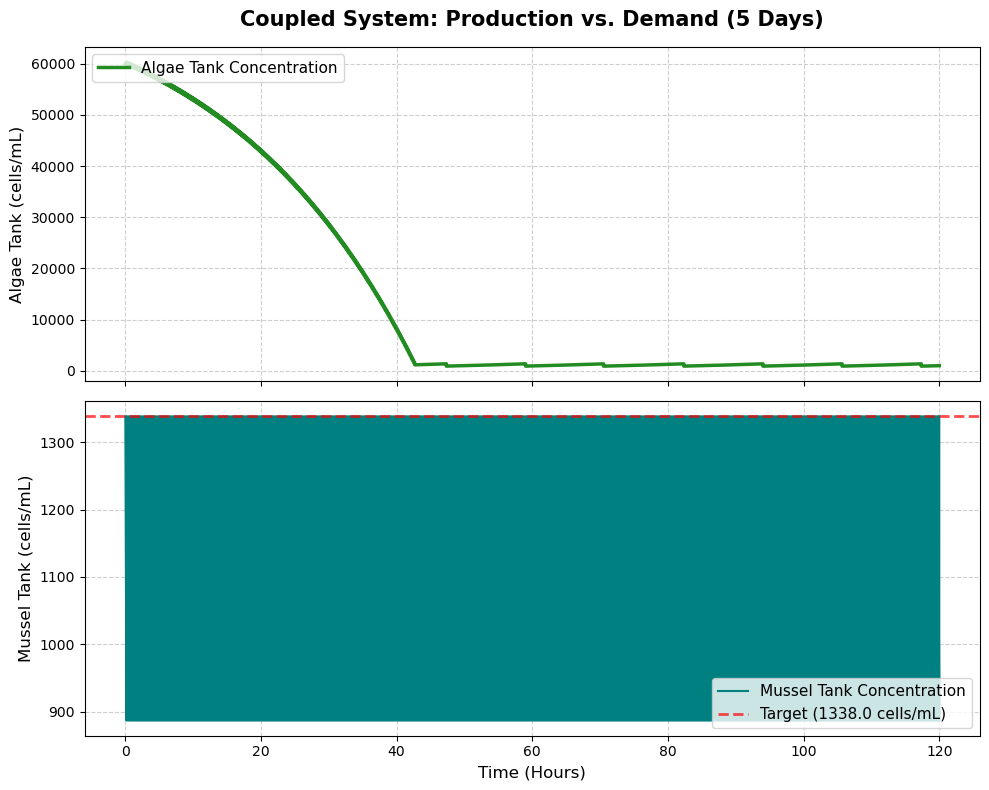

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
C_TARGET = 1338.0      # Target concentration (cells/mL)
F_RATE = 2.5          # Clearance rate (Liters/hour)
N_MUSSELS = 4          # Number of mussels
V_TANK = 4.0           # Mussel tank volume (Liters)
TIME_T = 10 / 60.0     # Sampling interval (10 minutes in hours)
DAYS_TO_SIMULATE = 5   # Simulate over 5 days to see long-term trends
CYCLES = int((DAYS_TO_SIMULATE * 24) / TIME_T) 

# --- Algae Reservoir Parameters ---
V_ALGAE = 4         # Algae tank volume (Liters) -> Assumed 10L, change if needed
C_ALGAE_INIT = 60000 # Initial Algae reservoir concentration (cells/mL)
MU_MAX = 0.035         # Constant specific growth rate (mu) in hr^-1

def simulate_coupled_system():
    """Simulates the two-tank system tracking both algae production and mussel demand."""
    time_points = []
    mussel_conc_points = []
    algae_conc_points = []
    
    current_time = 0.0
    c_mussel = C_TARGET
    c_algae = C_ALGAE_INIT
    
    for _ in range(CYCLES):
        # --- 1. Continuous Phase (10 minutes of Growth & Grazing) ---
        # Mussel tank net rate (growth minus grazing)
        g = (F_RATE * N_MUSSELS) / V_TANK
        net_mussel_rate = MU_MAX - g
        
        # Generate points for a smooth exponential curve
        t_local = np.linspace(0, TIME_T, 10)
        c_m_local = c_mussel * np.exp(net_mussel_rate * t_local)
        
        # Algae tank just grows (pure exponential)
        c_a_local = c_algae * np.exp(MU_MAX * t_local)
        
        # Add these continuous points to our plotting lists
        time_points.extend(current_time + t_local)
        mussel_conc_points.extend(c_m_local)
        algae_conc_points.extend(c_a_local)
        
        # Move clock forward
        current_time += TIME_T
        
        # The concentrations right before the pump turns on
        c_m_end = c_m_local[-1]
        c_a_end = c_a_local[-1]
        
        # --- 2. Discrete Dosing & Siphon Phase ---
        v_pumped = 0.0
        if c_a_end > C_TARGET:
            # Volume needed to bring mussel tank back to C_TARGET
            v_pumped = V_TANK * (C_TARGET - c_m_end) / (c_a_end - c_m_end)
            
        # Mussel tank reaches exact target
        c_m_new = C_TARGET
        
        # Siphon Effect on Algae Tank:
        # It keeps (V_ALGAE - v_pumped) of its own highly concentrated water,
        # and receives v_pumped of the mussel tank's low-concentration water (c_m_end)
        c_a_new = ((c_a_end * (V_ALGAE - v_pumped)) + (c_m_end * v_pumped)) / V_ALGAE
        
        # Record the instantaneous volume exchange spike
        time_points.append(current_time)
        mussel_conc_points.append(c_m_new)
        algae_conc_points.append(c_a_new)
        
        # Update states for the next cycle
        c_mussel = c_m_new
        c_algae = c_a_new
        
    return time_points, mussel_conc_points, algae_conc_points

# --- Generate Data ---
times, m_concentrations, a_concentrations = simulate_coupled_system()

# --- Console Output Analysis ---
print(f"--- 5-Day Simulation Results ---")
print(f"Initial Algae Reservoir: {C_ALGAE_INIT:,.0f} cells/mL")
print(f"Final Algae Reservoir:   {a_concentrations[-1]:,.0f} cells/mL")

if a_concentrations[-1] > C_ALGAE_INIT:
    print("VERDICT: Production EXCEEDS demand! Your algae culture will sustain the mussels.")
else:
    print("VERDICT: Demand exceeds production! The algae reservoir is slowly being depleted.")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Algae Reservoir (Top)
ax1.plot(times, a_concentrations, color='forestgreen', linewidth=2.5, label='Algae Tank Concentration')
ax1.set_title('Coupled System: Production vs. Demand (5 Days)', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Algae Tank (cells/mL)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11)

# Plot 2: Mussel Tank (Bottom)
ax2.plot(times, m_concentrations, color='teal', linewidth=1.5, label='Mussel Tank Concentration')
ax2.axhline(y=C_TARGET, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({C_TARGET} cells/mL)')
ax2.set_xlabel('Time (Hours)', fontsize=12)
ax2.set_ylabel('Mussel Tank (cells/mL)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('coupled_system_simulation.png', dpi=300)
plt.show()

--- Calculating Equilibrium State ---
--- 5-Day Simulation Results ---
Feeding Interval: 10 minutes
Minimum Concentration Drop: 1326 cells/mL
Equilibrium Algae Reservoir Start: 115,172.9 cells/mL
Equilibrium Algae Reservoir End:   115,171.6 cells/mL


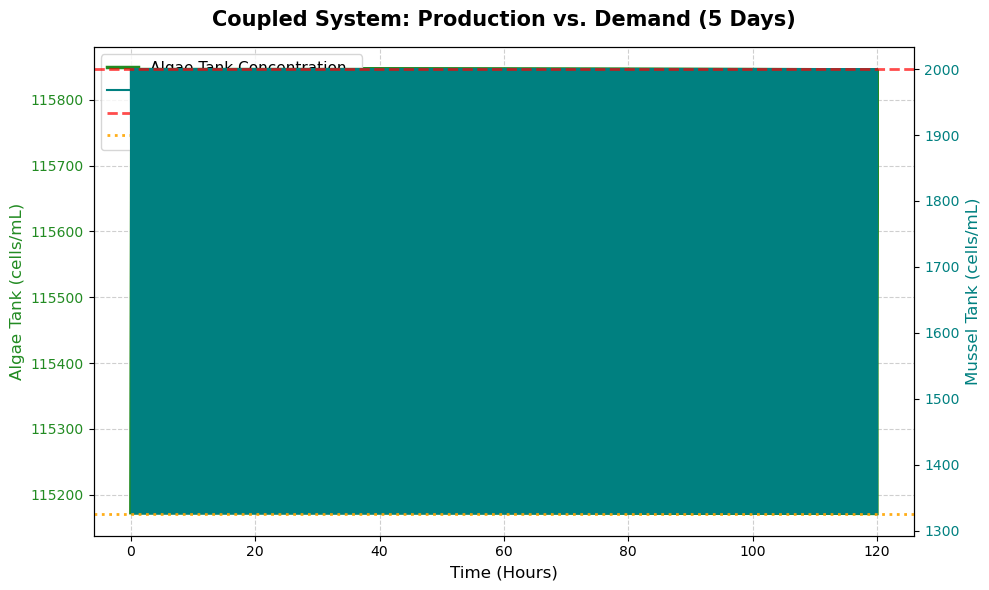

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
C_TARGET = 2000      # Target concentration (cells/mL)
F_RATE = 2.5          # Clearance rate (Liters/hour)
N_MUSSELS = 4         # Number of mussels
V_TANK = 4.0           # Mussel tank volume (Liters)
MU_MAX = 0.035         # Constant specific growth rate (mu) in hr^-1

# --- ADJUST THE FEEDING RATE (INTERVAL) HERE ---
FEED_INTERVAL_MINUTES = 10  # After how much time should we refeed the mussels?
TIME_T = FEED_INTERVAL_MINUTES / 60.0  # Convert to hours

# Calculate what the minimum concentration will drop to before the next feeding
g_rate = (F_RATE * N_MUSSELS) / V_TANK
net_mussel_rate_constant = MU_MAX - g_rate
C_MIN_REACHED = C_TARGET * math.exp(net_mussel_rate_constant * TIME_T)

DAYS_TO_SIMULATE = 5   # Simulate over 5 days to see long-term trends
CYCLES = int((DAYS_TO_SIMULATE * 24) / TIME_T) 

# --- Algae Reservoir Parameters ---
V_ALGAE = 4        # Algae tank volume (Liters) -> Assumed 10L, change if needed
# C_ALGAE_INIT will now be determined by our search loop below

def simulate_coupled_system(initial_algae_conc):
    """Simulates the two-tank system tracking both algae production and mussel demand."""
    time_points = []
    mussel_conc_points = []
    algae_conc_points = []
    
    current_time = 0.0
    c_mussel = C_TARGET
    c_algae = initial_algae_conc
    
    for _ in range(CYCLES):
        # --- 1. Continuous Phase (Growth & Grazing) ---
        # Generate points for a smooth exponential curve
        t_local = np.linspace(0, TIME_T, 10)
        c_m_local = c_mussel * np.exp(net_mussel_rate_constant * t_local)
        
        # Algae tank just grows (pure exponential)
        c_a_local = c_algae * np.exp(MU_MAX * t_local)
        
        # Add these continuous points to our plotting lists
        time_points.extend(current_time + t_local)
        mussel_conc_points.extend(c_m_local)
        algae_conc_points.extend(c_a_local)
        
        # Move clock forward
        current_time += TIME_T
        
        # The concentrations right before the pump turns on
        c_m_end = c_m_local[-1]
        c_a_end = c_a_local[-1]
        
        # --- 2. Discrete Dosing & Siphon Phase ---
        # The formula can ONLY be fulfilled if the algae tank is denser than the target
        if c_a_end > C_TARGET:
            # Volume needed to bring mussel tank back to C_TARGET
            v_pumped = V_TANK * (C_TARGET - c_m_end) / (c_a_end - c_m_end)
            
            # Safety Check: Ensure the formula doesn't demand more volume than we physically have
            if v_pumped <= V_ALGAE:
                # Formula is fulfilled! Adjust concentrations based on mass balance
                c_m_new = C_TARGET
                
                # Siphon Effect on Algae Tank:
                c_a_new = ((c_a_end * (V_ALGAE - v_pumped)) + (c_m_end * v_pumped)) / V_ALGAE
            else:
                # Algae is denser than target, but not dense enough to avoid pumping the whole tank
                c_m_new = c_m_end
                c_a_new = c_a_end
        else:
            # Algae tank is less dense than target, formula cannot be fulfilled mathematically
            c_m_new = c_m_end
            c_a_new = c_a_end
        
        # Record the instantaneous volume exchange spike (or flat line if not fulfilled)
        time_points.append(current_time)
        mussel_conc_points.append(c_m_new)
        algae_conc_points.append(c_a_new)
        
        # Update states for the next cycle
        c_mussel = c_m_new
        c_algae = c_a_new
        
    return time_points, mussel_conc_points, algae_conc_points

# --- Search Loop to Find Equilibrium Concentration ---
print("--- Calculating Equilibrium State ---")
low_bound = C_TARGET
high_bound = 1_000_000.0  # Set a high upper limit for the search
tolerance = 0.1           # Acceptable difference between start and end (cells/mL)

# Binary search loop
while (high_bound - low_bound) > tolerance:
    mid_conc = (low_bound + high_bound) / 2.0
    _, _, a_conc = simulate_coupled_system(mid_conc)
    
    final_conc = a_conc[-1]
    
    if final_conc > mid_conc:
        # Production > Demand (Tank is growing) -> We need a smaller initial concentration
        high_bound = mid_conc
    else:
        # Demand > Production (Tank is depleting) -> We need a larger initial concentration
        low_bound = mid_conc

# The loop exits when we find the perfectly balanced concentration
C_ALGAE_INIT = (low_bound + high_bound) / 2.0

# --- Generate Final Plotting Data ---
times, m_concentrations, a_concentrations = simulate_coupled_system(C_ALGAE_INIT)

# --- Console Output Analysis ---
print(f"--- 5-Day Simulation Results ---")
print(f"Feeding Interval: {FEED_INTERVAL_MINUTES} minutes")
print(f"Minimum Concentration Drop: {C_MIN_REACHED:.0f} cells/mL")
print(f"Equilibrium Algae Reservoir Start: {C_ALGAE_INIT:,.1f} cells/mL")
print(f"Equilibrium Algae Reservoir End:   {a_concentrations[-1]:,.1f} cells/mL")

if abs(a_concentrations[-1] - C_ALGAE_INIT) <= tolerance * 2:
    print("VERDICT: Perfect Equilibrium Reached! The system is entirely self-sustaining.")

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Algae Reservoir (Left Y-Axis)
color1 = 'forestgreen'
ax1.set_xlabel('Time (Hours)', fontsize=12)
ax1.set_ylabel('Algae Tank (cells/mL)', color=color1, fontsize=12)
line1 = ax1.plot(times, a_concentrations, color=color1, linewidth=2.5, label='Algae Tank Concentration')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Mussel Tank (Right Y-Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color2 = 'teal'
ax2.set_ylabel('Mussel Tank (cells/mL)', color=color2, fontsize=12)
line2 = ax2.plot(times, m_concentrations, color=color2, linewidth=1.5, label='Mussel Tank Concentration')
line3 = ax2.axhline(y=C_TARGET, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({C_TARGET} cells/mL)')
line4 = ax2.axhline(y=C_MIN_REACHED, color='orange', linestyle=':', linewidth=2, alpha=0.9, label=f'Min Drop ({C_MIN_REACHED:.0f} cells/mL)')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2 + [line3, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Coupled System: Production vs. Demand (5 Days)', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig('coupled_system_simulation.png', dpi=300)
plt.show()